<div style="background-color: #84bfef; padding: 20px; border-radius: 10px">

# Desafío #3 | EDA RRHH
</div>


## 1. Objetivo del análisis

Este EDA busca entender si el dataset de RRHH permite responder las preguntas del desafío, detectar problemas de calidad y preparar criterios para el análisis posterior y el dashboard.

El análisis contempla dos áreas:

- **Analista de Perfil y Desempeño Profesional**: Evalúa la influencia de factores críticos como la antigüedad, la carga laboral diaria y la distancia al centro de trabajo en el rendimiento de los colaboradores (Hit_target). El objetivo es identificar perfiles con mayor riesgo de bajo desempeño para proponer ajustes que potencien los resultados.

- **Analista de Absentismo y Benestar Laboral**: Examina cómo el comportamiento social (consumo de alcohol y tabaco) y los antecedentes disciplinarios condicionan los niveles de absentismo. Esta dimensión busca fundamentar el diseño de acciones preventivas y culturales que fomenten un entorno laboral saludable y minimicen las ausencias.

El EDA no limpia ni transforma definitivamente los datos. Solo identifica hallazgos, riesgos e incidencias que deberán tratarse en la fase de limpieza.


## 2. Librerías


In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm


## 3. Carga de datos

El dataset se lee desde el archivo CSV versionado en el repositorio local:

`Data/raw/raw_data.csv`

Se usa ruta local del proyecto, no la URL de GitHub, para que el notebook funcione dentro de cualquier clon de la rama.


In [224]:
DATA_FILE = '../../Data/raw/raw_data_08062026.csv' # Cambio Pte nombre CSV
RRHH = pd.read_csv(DATA_FILE)

### 3.1 CONTROL DE REGISTROS

In [225]:
def control_registros(df):

    fecha_actual = date.today()

    total_registros = df.shape[0]
    ID_unicos = df['ID'].nunique()
    ID_extra = total_registros - ID_unicos
    ID_duplicados_exactos = df[df.duplicated(keep=False)].drop_duplicates().shape[0]


    print('--------------------\nCONTROL DE REGISTROS\n--------------------')
    print(f'Fecha: {fecha_actual}\n--------------------')
    print(f'TOTAL REGISTROS: {total_registros}')
    print(f'ID ÚNICOS: {ID_unicos}')
    print(f'ID EXTRAS: {ID_extra}')
    print(f'ID DUPLICADOS EXACTOS: {ID_duplicados_exactos}')

In [226]:
control_registros(RRHH)

--------------------
CONTROL DE REGISTROS
--------------------
Fecha: 2026-06-11
--------------------
TOTAL REGISTROS: 1110
ID ÚNICOS: 386
ID EXTRAS: 724
ID DUPLICADOS EXACTOS: 41


## 4. Vistazo inicial

Se revisa tamaño, columnas, tipos de datos y muestra inicial para entender cómo llega el dataset antes de analizarlo.


In [227]:
estructura_inicial = pd.DataFrame({
    "columna": RRHH.columns,
    "tipo_dato": RRHH.dtypes.astype(str).values,
    "nulos": RRHH.isna().sum().values,
    "vacios_texto": [
        RRHH[col].astype(str).str.strip().eq("").sum()
        for col in RRHH.columns
    ],
    "valores_unicos": RRHH.nunique().values
})

estructura_inicial


,columna,tipo_dato,nulos,vacios_texto,valores_unicos
0,ID,int64,0,0,386
1,Reason_absence,int64,0,0,28
2,Month_absence,int64,0,0,13
3,Day_week,int64,0,0,5
4,Seasons,int64,0,0,4
5,Transportation_expense,int64,0,0,24
6,Distance_Residence_Work,int64,0,0,25
7,Service_time,int64,0,0,18
8,Age,int64,0,0,22
9,Work_load_Average_day,object,0,0,38


    "El análisis se centra en cuatro pilares críticos para la organización:

Hit_target: Nuestra métrica principal de desempeño (81-100%). Buscamos entender qué factores provocan las caídas hacia el límite inferior.

Absenteeism_hours: Indicador de bienestar y salud laboral. El objetivo es identificar patrones para el diseño de acciones preventivas.

Service_time: Representa la lealtad y el conocimiento institucional. Analizaremos si el compromiso se mantiene o decae con la antigüedad.

Distance_Residence_Work: Factor logístico clave que impacta en el agotamiento y estrés del colaborador."

In [228]:
RRHH.describe(include="all")


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
count,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110,...,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"222,196",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,79.075676,18.977477,6.381982,3.902703,2.536937,221.316216,29.504505,12.652252,36.639640,NaN,...,0.058559,1.276577,1.059459,0.567568,0.084685,0.760360,79.036937,172.072072,26.683784,9.148649
std,106.713785,8.479564,3.414555,1.434312,1.116313,66.585525,14.798237,4.369103,6.657935,NaN,...,0.234902,0.653830,1.104983,0.495637,0.278537,1.318611,12.768292,6.022518,4.244554,19.681194
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,NaN,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,13.250000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,NaN,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,28.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,NaN,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,108.750000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,NaN,...,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000


**Observación EDA:** `Work_load_Average_day` aparece como texto aunque representa una variable numérica. En esta fase se documenta el problema, pero la conversión definitiva corresponde a limpieza.


### Distribución de la variables Numéricas

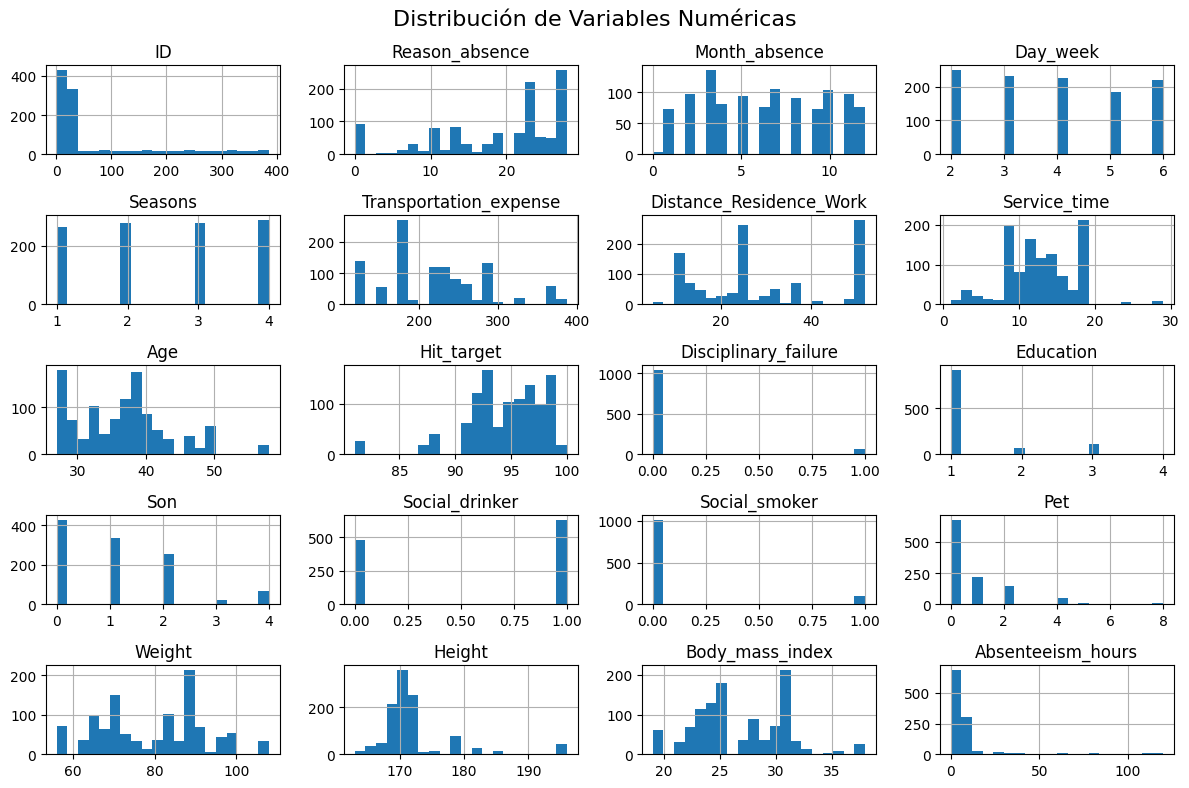

In [229]:
RRHH.hist(figsize=(12,8), bins=20)
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

### Descripción de variables con enfoque de negocio

**Hit_target**: Variable de desempeño (81-100%). Objetivo: Identificar qué factores la reducen.

**Absenteeism_hours**: Variable de bienestar. Objetivo: Minimizar este impacto con acciones preventivas.

**Service_time**: Antigüedad en la empresa. ¿Influye el compromiso con los años?

**Distance_Residence_Work**: Distancia al trabajo. Factor clave en el cansancio y estrés del colaborador.

## 5. Unidad de análisis

Una fila no representa necesariamente un empleado único, sino un registro de solicitud de ausencia


In [230]:
unidad_analisis = pd.DataFrame({
    "Métrica": [
        "Total registros",
        "IDs únicos",
        "Media de registros por ID",
        "Máximo de registros en un ID",
        "Registros con Absenteeism_hours = 0"
    ],
    "Resultado": [
        len(RRHH),
        RRHH["ID"].nunique(),
        round(RRHH.groupby("ID").size().mean(), 2),
        RRHH.groupby("ID").size().max(),
        (RRHH["Absenteeism_hours"] == 0).sum()
    ]
})

unidad_analisis


,Métrica,Resultado
0,Total registros,1110.00
1,IDs únicos,386.00
2,Media de registros por ID,2.88
3,Máximo de registros en un ID,113.00
4,Registros con Absenteeism_hours = 0,71.00


## 6. Calidad inicial de datos

Se revisan nulos, vacíos, IDs repetidos, duplicados exactos y valores especiales. En esta fase no se corrige nada: solo se identifican incidencias para limpieza.


In [231]:
columnas_rrhh = RRHH.columns.tolist()

duplicados_exactos_por_fila = (
    RRHH
    .groupby(columnas_rrhh, dropna=False)
    .size()
    .reset_index(name="times_repeated")
    .query("times_repeated > 1")
)

ids_con_duplicados_exactos = (
    duplicados_exactos_por_fila["ID"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

control_calidad_registros = pd.DataFrame({
    "Métrica": [
        "Total registros",
        "IDs únicos",
        "ID extras",
        "Duplicados exactos extra",
        "Filas involucradas en duplicados exactos",
        "Grupos exactos duplicados",
        "IDs con duplicados exactos"
    ],
    "Resultado": [
        len(RRHH),
        RRHH["ID"].nunique(),
        len(RRHH) - RRHH["ID"].nunique(),
        RRHH.duplicated(keep="first").sum(),
        RRHH.duplicated(keep=False).sum(),
        len(duplicados_exactos_por_fila),
        ids_con_duplicados_exactos.nunique()
    ],
    "Cómo se interpreta": [
        "Total de filas",
        "Empleados distintos",
        "Apariciones adicionales de IDs repetidos",
        "Filas repetidas completas",
        "Originales + duplicadas",
        "Combinaciones de fila completa repetida",
        "IDs afectados por filas exactamente repetidas"
    ]
})

control_calidad_registros


,Métrica,Resultado,Cómo se interpreta
0,Total registros,1110,Total de filas
1,IDs únicos,386,Empleados distintos
2,ID extras,724,Apariciones adicionales de IDs repetidos
3,Duplicados exactos extra,54,Filas repetidas completas
4,Filas involucradas en duplicados exactos,95,Originales + duplicadas
5,Grupos exactos duplicados,41,Combinaciones de fila completa repetida
6,IDs con duplicados exactos,16,IDs afectados por filas exactamente repetidas


In [232]:
revision_nulos_vacios = pd.DataFrame({
    "columna": RRHH.columns,
    "nulos": RRHH.isna().sum().values,
    "vacios": [
        RRHH[col].astype(str).str.strip().eq("").sum()
        for col in RRHH.columns
    ]
})

revision_nulos_vacios["total_nulos_o_vacios"] = (
    revision_nulos_vacios["nulos"] + revision_nulos_vacios["vacios"]
)

revision_nulos_vacios


,columna,nulos,vacios,total_nulos_o_vacios
0,ID,0,0,0
1,Reason_absence,0,0,0
2,Month_absence,0,0,0
3,Day_week,0,0,0
4,Seasons,0,0,0
5,Transportation_expense,0,0,0
6,Distance_Residence_Work,0,0,0
7,Service_time,0,0,0
8,Age,0,0,0
9,Work_load_Average_day,0,0,0


## 7. Visualización variables

Se revisan en profundidad distribuciones de variables fundamentales para entender rangos, concentración de valores y posibles valores extremos.


In [233]:
variables_fundamentales = [
    "Age",
    "Service_time",
    "Distance_Residence_Work",
    "Transportation_expense",
    "Hit_target",
    "Body_mass_index",
    "Absenteeism_hours"
]

RRHH[variables_fundamentales].describe().round(2)


,Age,Service_time,Distance_Residence_Work,Transportation_expense,Hit_target,Body_mass_index,Absenteeism_hours
count,1110.00,1110.00,1110.0,1110.00,1110.00,1110.00,1110.00
mean,36.64,12.65,29.5,221.32,94.63,26.68,9.15
std,6.66,4.37,14.8,66.59,3.75,4.24,19.68
min,27.00,1.00,5.0,118.00,81.00,19.00,0.00
25%,31.00,9.00,16.0,179.00,93.00,24.00,2.00
50%,37.00,13.00,26.0,225.00,95.00,25.00,3.00
75%,40.00,16.00,50.0,260.00,97.00,31.00,8.00
max,58.00,29.00,52.0,388.00,100.00,38.00,120.00


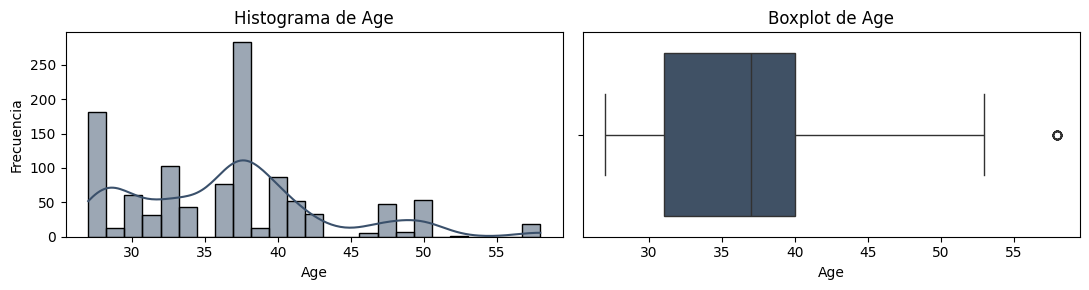

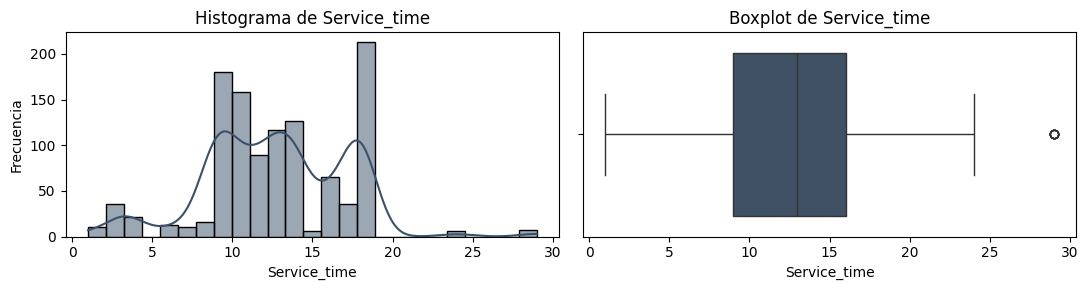

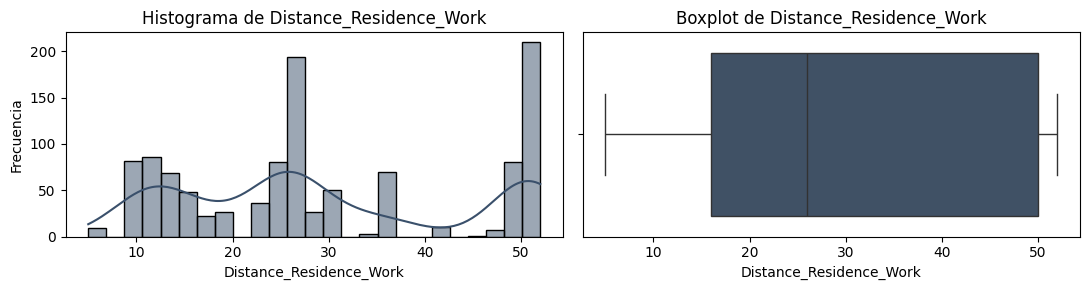

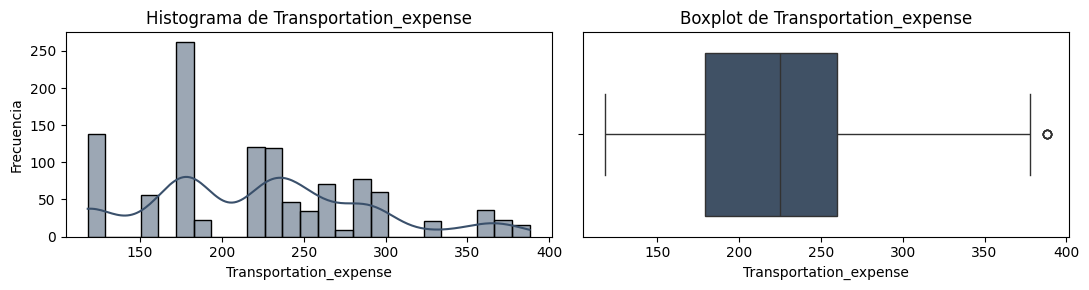

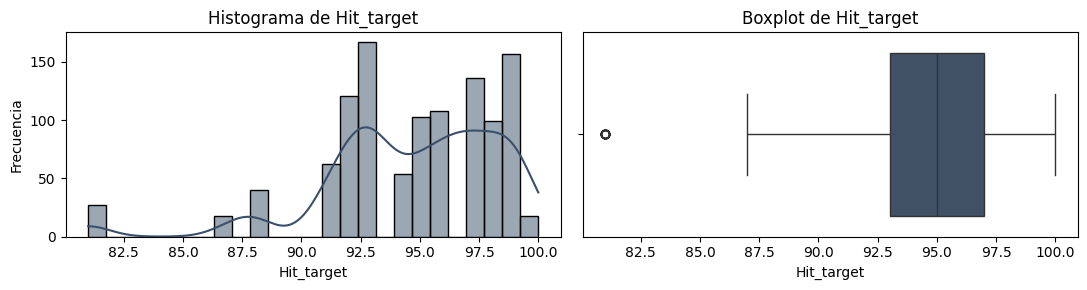

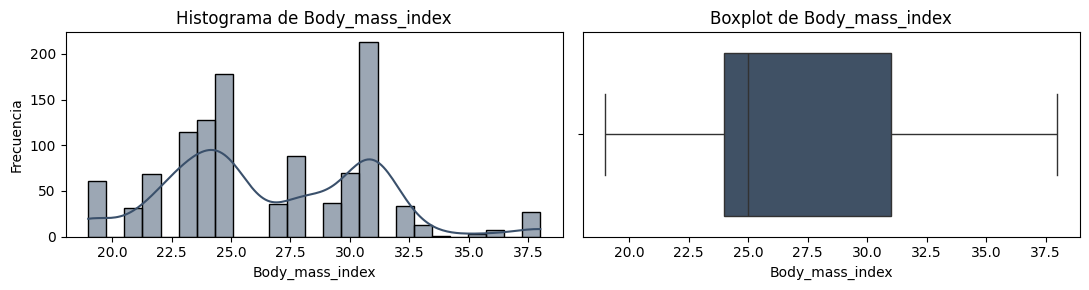

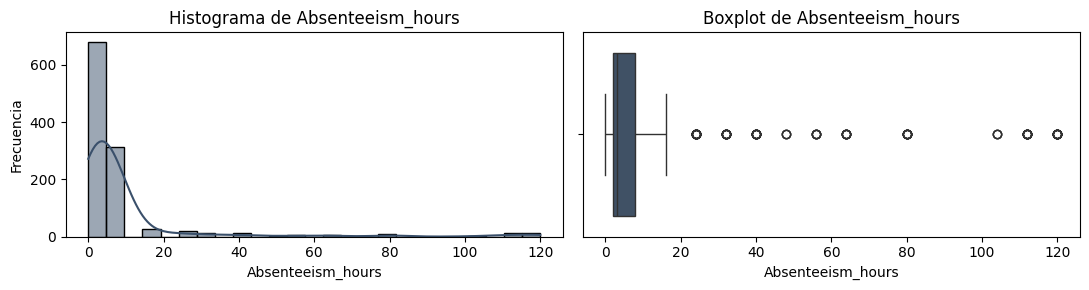

In [234]:
color_principal = "#3A506B"

for variable in variables_fundamentales:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))

    sns.histplot(data=RRHH, x=variable, bins=25, kde=True, color=color_principal, ax=axes[0])
    axes[0].set_title(f"Histograma de {variable}")
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel("Frecuencia")

    sns.boxplot(data=RRHH, x=variable, color=color_principal, ax=axes[1])
    axes[1].set_title(f"Boxplot de {variable}")
    axes[1].set_xlabel(variable)

    plt.tight_layout()
    plt.show()


## Identificación de Outliers por Porcentaje

In [235]:
def get_outliers_percentage(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
    return (len(outliers) / len(df)) * 100


In [236]:
RRHH['Work_load_Average_day'] = (
    RRHH['Work_load_Average_day']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

RRHH['Work_load_Average_day'] = pd.to_numeric(
    RRHH['Work_load_Average_day'],
    errors='coerce'
)


Se puede considerar este cambio de tipo como algo correspondiente a limpieza de datos, sin embargo, lo realizamos aquí para poder proceder con el EDA.

In [237]:
outlier_results = {col: get_outliers_percentage(RRHH, col) for col in cols_interes}

outlier_results = dict(
    sorted(
        outlier_results.items(),
        key=lambda x: x[1],
        reverse=True
    )
)


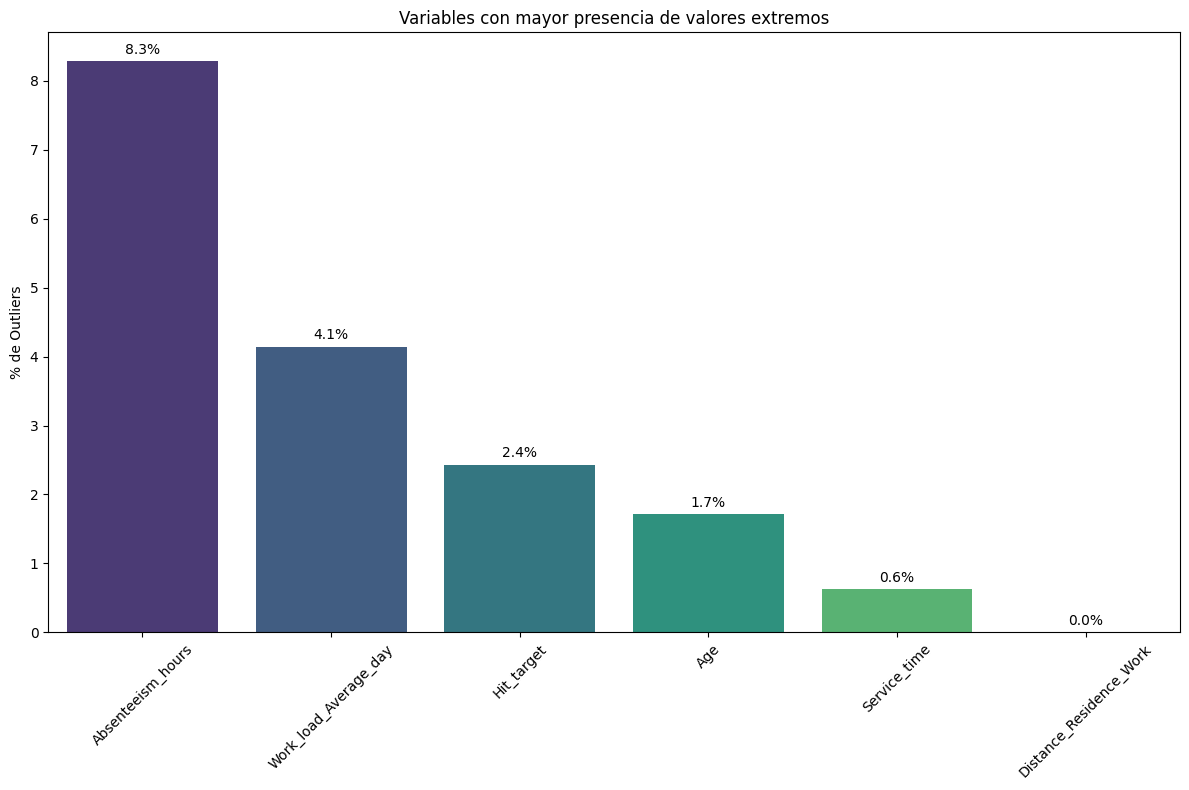

In [238]:
outliers_df = pd.DataFrame({
    'Variable': list(outlier_results.keys()),
    '% Outliers': list(outlier_results.values())
}).sort_values('% Outliers', ascending=False)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=outliers_df,
    x='Variable',
    y='% Outliers',
    hue='Variable',
    legend=False,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.title('Variables con mayor presencia de valores extremos')
plt.ylabel('% de Outliers')
plt.xlabel('')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Este grafico nos permite identificar qué variables (como las horas de absentismo) tienen comportamientos más extremos y requieren mayor atención en la organización

Se observa que la variable Absenteeism_hours presenta el mayor volumen de valores extremos (8.3%), seguida por la carga laboral diaria (4.1%). Esto indica que el absentismo no es un problema uniforme en toda la empresa, sino que está concentrado en incidentes específicos de larga duración que requieren una gestión individualizada, más que una política general.

### 7.1 Visualización avanzada de categorías (Bar + Pie)

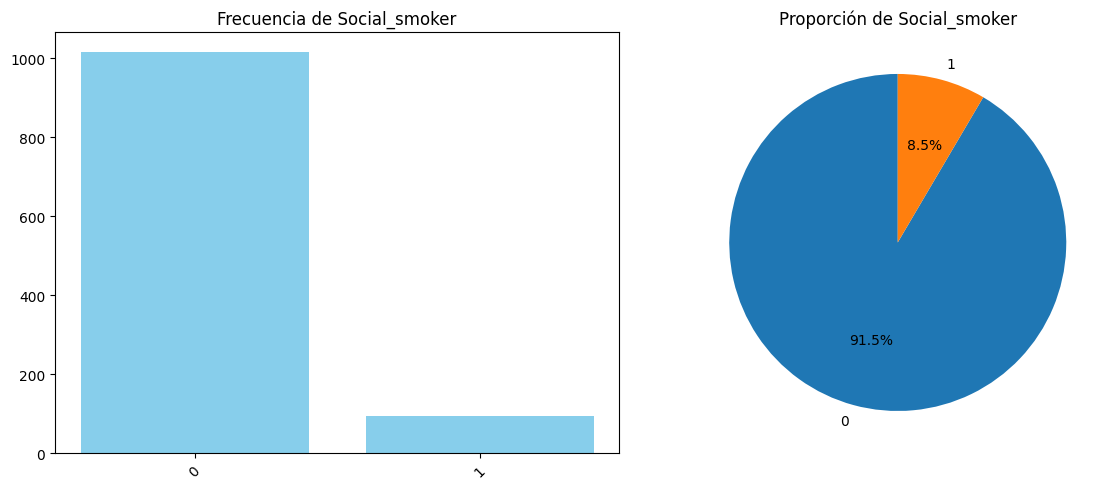

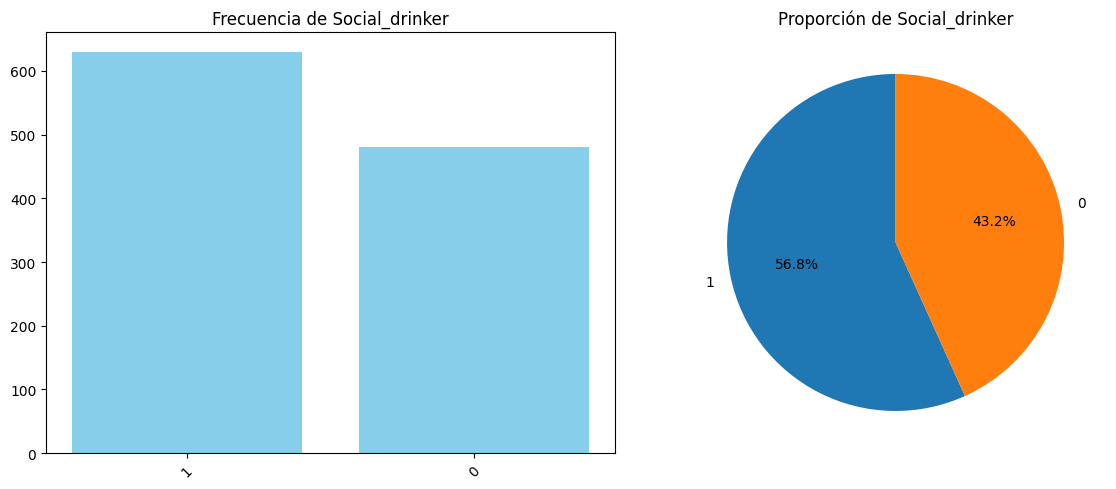

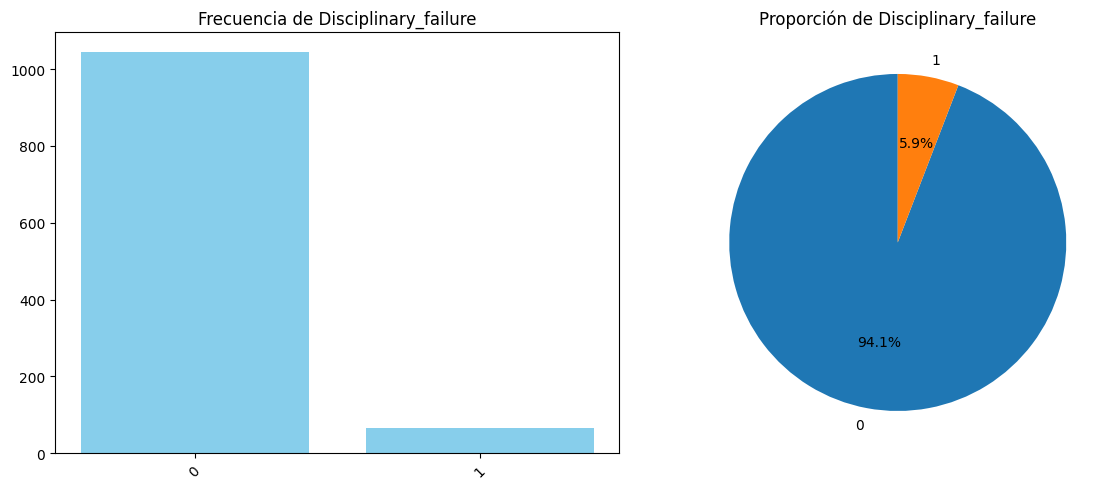

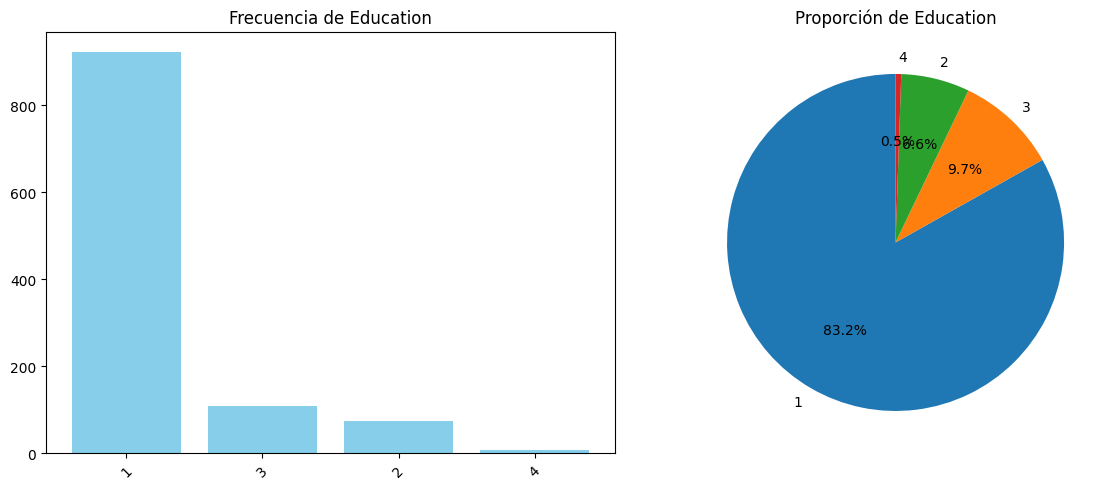

In [239]:
cat_vars = ['Social_smoker', 'Social_drinker', 'Disciplinary_failure', 'Education']

for var in cat_vars:
    counts = RRHH[var].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico de barras
    axes[0].bar(counts.index.astype(str), counts.values, color='skyblue')
    axes[0].set_title(f'Frecuencia de {var}')
    axes[0].tick_params(axis='x', rotation=45)

    #Gráfico de tarta
    axes[1].pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {var}')

    plt.tight_layout()
    plt.show()

"El perfil socioconductual de la plantilla muestra un claro desequilibrio en el consumo de tabaco (solo el 8.5% son fumadores sociales), mientras que el consumo social de alcohol está más extendido (56.8%). En cuanto al nivel educativo, la categoría 1 es dominante (83.2%), lo que sugiere una fuerza laboral con perfiles técnicos o de ejecución similares."

## 8. Análisis relaciones clave

Se exploran relaciones directamente conectadas con las preguntas de negocio


## Matriz de Correlación Enfocada a Negocio

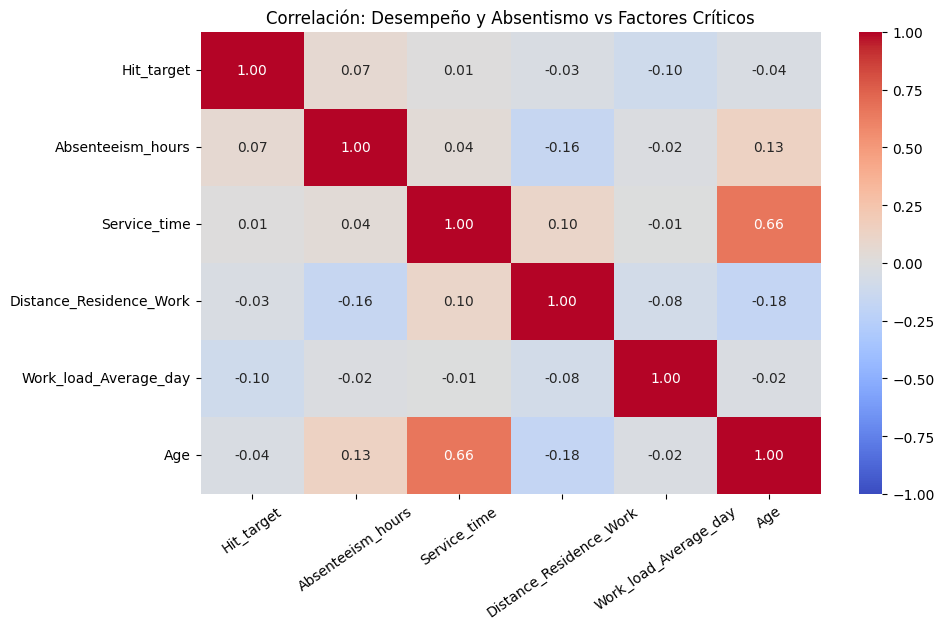

In [240]:
#Seleccionamos variables clave para las preguntas de negocio
cols_interes = [
    'Hit_target', 'Absenteeism_hours', 'Service_time',
    'Distance_Residence_Work', 'Work_load_Average_day', 'Age'
]

corr = RRHH[cols_interes].corr()

# Normalización centrada en 0
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    norm=norm,
    fmt='.2f'
)

plt.title("Correlación: Desempeño y Absentismo vs Factores Críticos")
plt.xticks(rotation=35)
plt.yticks(rotation=0)

plt.show()

### Pregunta negocio: Perfil y Desempeño

#### 8.1 Antigüedad vs Hit_target

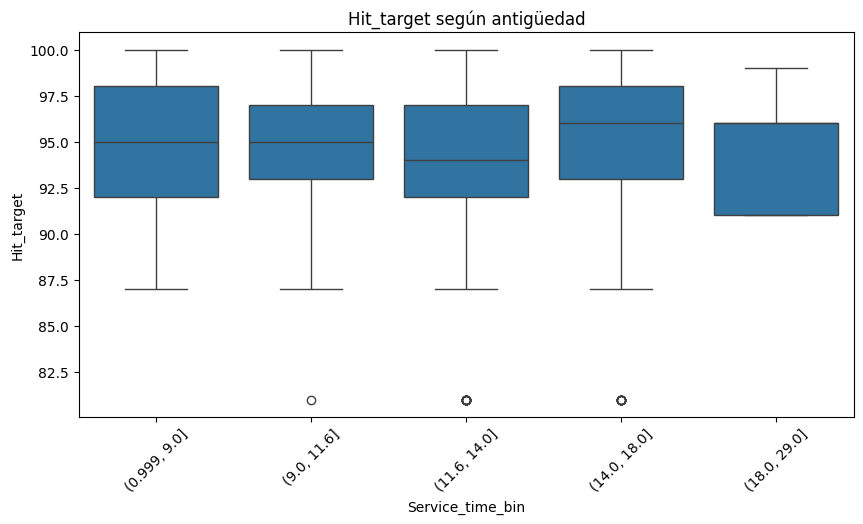

In [241]:
RRHH['Service_time_bin'] = pd.qcut(RRHH['Service_time'], 5)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=RRHH,
    x='Service_time_bin',
    y='Hit_target'
)

plt.xticks(rotation=45)
plt.title('Hit_target según antigüedad')
plt.show()

#### 8.2 Distancia vs Hit target

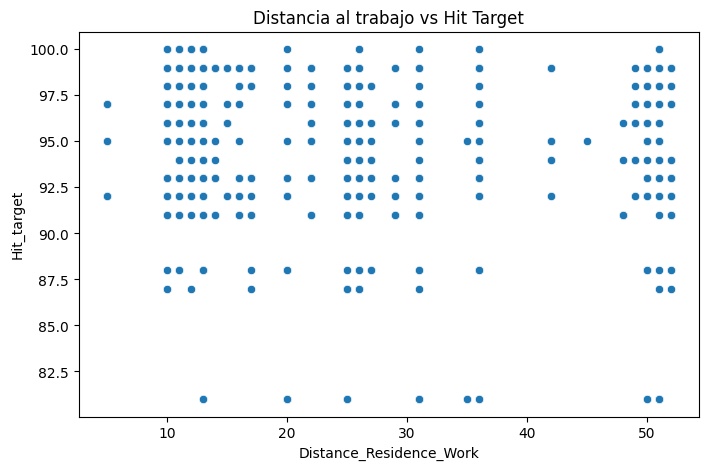

In [242]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=RRHH,
    x='Distance_Residence_Work',
    y='Hit_target'
)

plt.title('Distancia al trabajo vs Hit Target')
plt.show()

#### 8.3 Work load vs Hit_Target

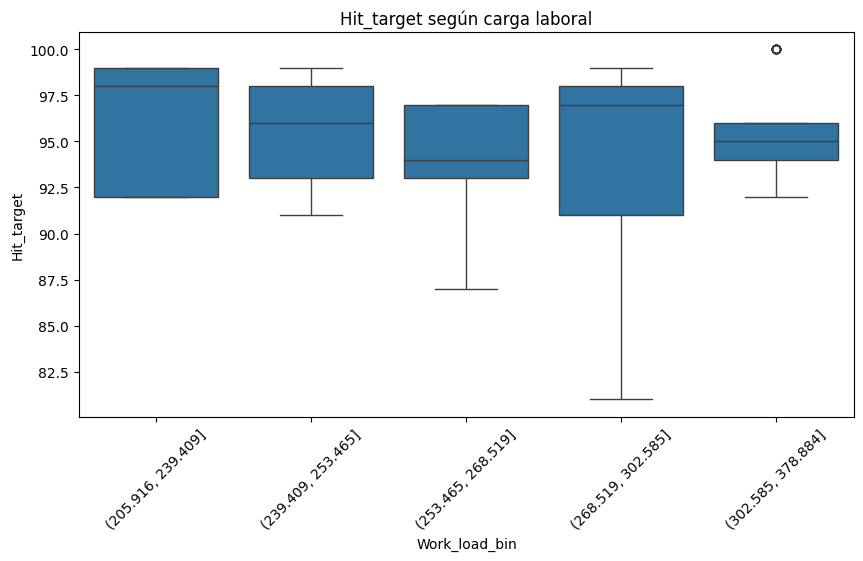

In [243]:
RRHH['Work_load_bin'] = pd.qcut(RRHH['Work_load_Average_day'], 5)
plt.figure(figsize=(10,5))

sns.boxplot(
    data=RRHH,
    x='Work_load_bin',
    y='Hit_target'
)

plt.xticks(rotation=45)
plt.title('Hit_target según carga laboral')
plt.show()

#### 8.4 Distancia vs Hit_target

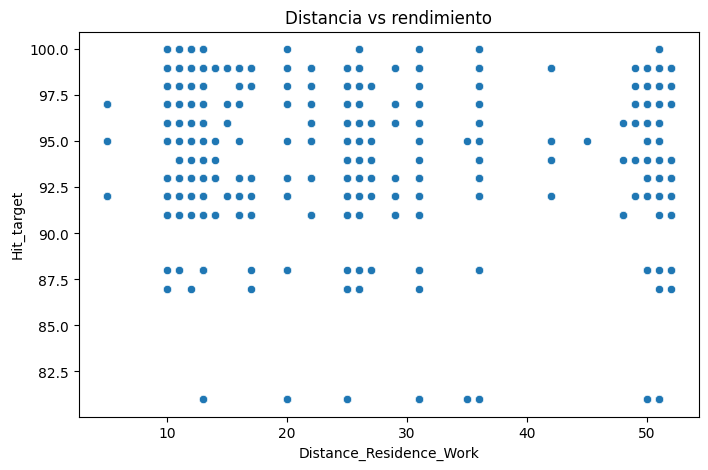

In [244]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=RRHH,
    x='Distance_Residence_Work',
    y='Hit_target'
)

plt.title('Distancia vs rendimiento')
plt.show()

#### Percentiles

In [245]:
RRHH['performance_level'] = pd.qcut(RRHH['Hit_target'], 3, labels=['Bajo', 'Medio', 'Alto'])

RRHH.groupby('performance_level')[[
    'Service_time',
    'Work_load_Average_day',
    'Distance_Residence_Work'
]].mean().round(2)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_463/1530237667.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  RRHH.groupby('performance_level')[[


,Service_time,Work_load_Average_day,Distance_Residence_Work
performance_level,,,
Bajo,12.47,263.55,30.09
Medio,12.80,289.00,30.48
Alto,12.73,252.91,27.14


Se observa una relación entre la logística y el rendimiento: los empleados con desempeño 'Alto' viven, en promedio, más cerca (27.14 km) que aquellos con desempeño 'Bajo' (30.09 km). Asimismo, el grupo de alto rendimiento soporta una carga laboral media menor (252.91) frente a los que rinden menos (263.55), sugiriendo que la saturación de tareas afecta directamente la calidad del trabajo.

#### Comportamiento de Hit target: Temporalidad

In [246]:
pd.crosstab(
    RRHH['Month_absence'],
    RRHH['Hit_target']
)



Hit_target,81,87,88,91,92,93,94,95,96,97,98,99,100
Month_absence,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,3,0,0,0,0,0
1,0,0,0,0,0,0,0,37,18,0,0,0,18
2,0,0,0,0,0,0,0,0,28,48,0,21,0
3,0,0,0,0,0,0,0,39,0,0,33,65,0
4,0,0,0,26,0,0,0,0,32,0,24,0,0
5,0,0,0,0,23,0,0,0,0,0,0,71,0
6,0,0,0,0,0,0,23,24,30,0,0,0,0
7,0,0,0,0,37,20,0,0,0,28,21,0,0
8,0,0,0,0,33,27,31,0,0,0,0,0,0


In [247]:
RRHH.groupby('Month_absence')['Hit_target'].unique()

Month_absence
0                 [95]
1        [100, 96, 95]
2         [96, 99, 97]
3         [99, 95, 98]
4         [98, 96, 91]
5             [99, 92]
6         [94, 95, 96]
7     [93, 92, 97, 98]
8         [92, 93, 94]
9         [81, 92, 87]
10        [88, 93, 91]
11            [97, 93]
12        [98, 97, 93]
Name: Hit_target, dtype: object

Teniendo en cuenta que raw_data empieza y termina en julio y que se estan anlizando un total de 3 años. Podemos deducir que el comportamiento de Hit_target es mensual

El month_ansence == 0 es un error a corregir en el datacleaning

In [248]:
hit_target_empleado_mes = (
    RRHH.groupby(['ID', 'Month_absence'])['Hit_target']
      .mean()
      .reset_index()
      .sort_values(['ID', 'Month_absence'])
)

In [249]:
hit_target_empleado_mes.head(20)

,ID,Month_absence,Hit_target
0,1,1,100.000000
1,1,3,98.000000
2,1,4,93.500000
3,1,5,99.000000
4,1,6,94.500000
5,1,7,95.000000
6,1,8,93.250000
7,1,10,88.000000
8,1,11,97.000000
9,1,12,94.000000


### Pregunta negocio de Absentismo

#### 8.5 Absentismo vs Social_smoker

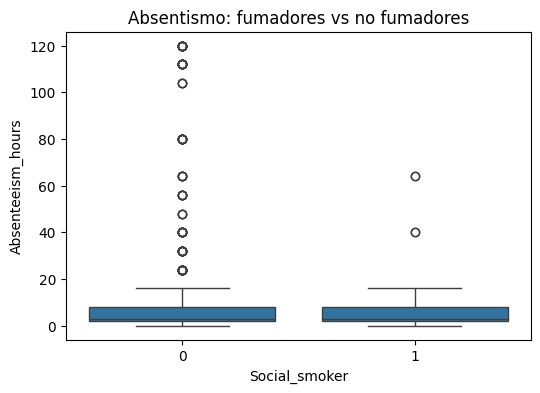

In [250]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=RRHH,
    x='Social_smoker',
    y='Absenteeism_hours'
)

plt.title('Absentismo: fumadores vs no fumadores')
plt.show()

#### 8.6 Absentismo vs Social_drinker

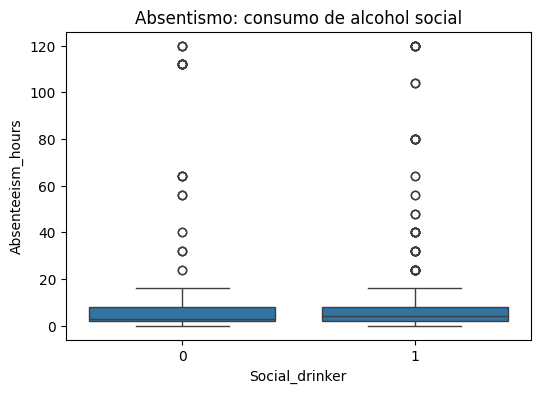

In [251]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=RRHH,
    x='Social_drinker',
    y='Absenteeism_hours'
)

plt.title('Absentismo: consumo de alcohol social')
plt.show()

#### 8.6 Absentismo vs Disciplinary_Failure

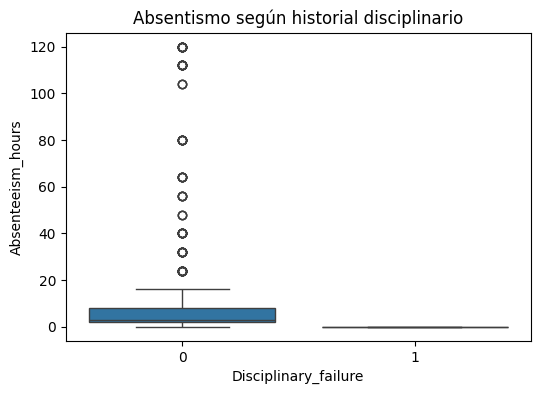

In [252]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=RRHH,
    x='Disciplinary_failure',
    y='Absenteeism_hours'
)

plt.title('Absentismo según historial disciplinario')
plt.show()

Cada vez que se registra Disciplinary Failure no se registra hora de ausencia

Se identifica un hallazgo crítico en la gestión administrativa: cada vez que se registra un fallo disciplinario, las horas de absentismo son cero. Esto implica que las sanciones detienen el registro de ausencias

## 9. Investigación de repetición por ID

Esta sección justifica por qué un mismo `ID` puede aparecer muchas veces. Si cambian meses, días, motivos u horas, las filas pueden representar situaciones distintas.


In [253]:
resumen_por_id = (
    RRHH
    .groupby("ID")
    .agg(
        total_filas=("ID", "count")
    )
    .sort_values("total_filas", ascending=False)
)

resumen_por_id.head(10)


,total_filas
ID,
3,113
28,78
34,57
22,47
20,43
11,41
36,37
15,37
14,33


## 10. Criterios para limpieza

Estos puntos no se resuelven en el EDA, pero sí afectan la interpretación y deben tratarse antes del dashboard final.


In [254]:
incidencias_limpieza = pd.DataFrame({
    "Incidencia": [
        "Duplicados exactos",
        "Work_load_Average_day como texto",
        "Month_absence = 0",
        "Reason_absence = 0",
        "Absenteeism_hours = 0",
        "Códigos sin diccionario",
        "Variables de perfil que cambian dentro de un mismo ID",
        "Unidad de análisis mixta"
    ],
    "Criterio propuesto": [
        "Revisar si se eliminan las filas repetidas completas sobrantes",
        "Convertir a numérico en limpieza, no en EDA",
        "Investigar si es código especial o dato no informado",
        "No interpretar sin diccionario de motivos",
        "Revisar si representa ausencia cero, registro administrativo o código especial",
        "Documentar equivalencias de Reason_absence, Day_week, Seasons y Education",
        "Revisar el ID 29 porque cambian edad, educación, distancia, peso, altura y BMI",
        "Separar análisis por registro y por empleado"
    ]
})

incidencias_limpieza


,Incidencia,Criterio propuesto
0,Duplicados exactos,Revisar si se eliminan las filas repetidas com...
1,Work_load_Average_day como texto,"Convertir a numérico en limpieza, no en EDA"
2,Month_absence = 0,Investigar si es código especial o dato no inf...
3,Reason_absence = 0,No interpretar sin diccionario de motivos
4,Absenteeism_hours = 0,"Revisar si representa ausencia cero, registro ..."
5,Códigos sin diccionario,"Documentar equivalencias de Reason_absence, Da..."
6,Variables de perfil que cambian dentro de un m...,"Revisar el ID 29 porque cambian edad, educació..."
7,Unidad de análisis mixta,Separar análisis por registro y por empleado


## 11. Hallazgos y conclusión final




Los siguientes hallazgos son primeras aproximaciones al dataset: se profundizara en técnicas de análisis en sus notebooks correspondiente.

#### A. Analista de Perfil y Desempeño Profesional
*   **Impacto de la Carga Laboral:** Se observa una correlación negativa leve (-0.10) entre la carga laboral diaria (`Work_load_Average_day`) y el desempeño (`Hit_target`). Los empleados con niveles de desempeño "Alto" presentan, en promedio, una carga laboral menor (252.91) frente a los de desempeño "Bajo" (263.55). **Conclusión:** Una carga excesiva parece "techar" o reducir ligeramente la eficiencia individual.

*   **Factor Distancia:** Los colaboradores con mejor rendimiento ("Alto") viven, en promedio, más cerca del trabajo (27.14 km) que aquellos con rendimiento "Bajo" (30.09 km). Aunque el scatterplot no muestra una relación lineal perfecta, la proximidad física facilita la estabilidad del rendimiento.

*   **Influencia de la Antigüedad:** El compromiso no decae drásticamente con los años, pero el grupo de mayor antigüedad (18-29 años) muestra una dispersión mayor en su rendimiento y una mediana ligeramente inferior al grupo de 14-18 años.

*   **Identificación de Perfiles de Riesgo:** El perfil con mayor riesgo de bajo rendimiento se concentra en empleados con **alta carga laboral diaria, mayor distancia de residencia** y que se encuentran en meses específicos de baja productividad, como el **mes 9**, donde se registran los valores mínimos de `Hit_target` (81%).

#### B. Analista de Absentismo y Bienestar Laboral
*   **Consumo Social (Alcohol y Tabaco):** 
    *   Los **bebedores sociales** muestran una mayor presencia de valores extremos (outliers) en horas de absentismo comparado con los no bebedores.

    *   Curiosamente, aunque los no fumadores tienen más registros totales, los fumadores sociales mantienen niveles de absentismo constantes, sin los picos extremos de ausencia que se ven en el resto de la población.

*   **Magnitud del Problema:** La variable `Absenteeism_hours` es la que presenta más valores extremos (8.3% de outliers), lo que indica que el absentismo no es un problema generalizado de toda la plantilla, sino concentrado en un grupo específico con ausencias de hasta 120 horas.

## 12. Propuestas de Acción (Estrategia Preventiva)
Basándome en tu EDA, estas son las acciones que podrías sugerir:
1.  **Flexibilidad por Distancia:** Implementar políticas de teletrabajo o flexibilidad horaria para el segmento que vive a más de 30km, ya que este grupo tiende a puntuar más bajo en el cumplimiento de objetivos (`Hit_target`).
2.  **Gestión de Carga en Meses Críticos:** Reforzar el apoyo u optimizar procesos durante el **mes 10 y mes 9**, periodos donde el rendimiento cae de forma generalizada en la organización.
3.  **Programa de Bienestar Focalizado:** Dado que el absentismo extremo está ligado a "bebedores sociales", diseñar campañas de salud enfocadas en este grupo para reducir las bajas de larga duración (outliers de 120 horas).
4.  **Revisión del ID 29:** Como hallazgo técnico urgente, se debe investigar el ID 29 en la fase de limpieza, ya que presenta cambios inconsistentes en variables fijas (edad, educación, altura), lo que podría estar sesgando los perfiles de riesgo identificados.
